## Problema - Organización y búsqueda de productos en una tienda





In [ ]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Una empresa de mensajería tiene varios centros de distribución (A–G) conectados por rutas terrestres. Cada centro es un **vértice** y cada carretera una **arista** de un **grafo no dirigido**, representado con una **lista de adyacencia**.

La empresa necesita un programa que:
- Muestre las conexiones de cada centro.
- Recorra la red con **BFS** (centros más cercanos al inicial, por niveles) y con **DFS** (inspección completa avanzando lo máximo por una ruta).
- Permita elegir el centro inicial y validar que exista.
- **Busque un centro** con BFS y muestre la ruta más corta y su cantidad de conexiones (o informe que no hay ruta).
- Permita **agregar nuevos centros y conexiones**, guardándolas en ambos sentidos, y volver a ejecutar los recorridos.

Restricciones: BFS con cola, DFS recursivo, cada vértice visitado una sola vez por recorrido y sin librerías que implementen BFS/DFS (solo se usa `collections.deque` como cola).

Red inicial: A–B, A–C, B–D, B–E, C–F, E–G, F–G.

## 2) Requerimientos **[2 pts]**

### Funcionales
- **RF1.** Representar la red con una lista de adyacencia y mostrar las conexiones de cada centro.
- **RF2.** Recorrer la red con BFS desde un centro y mostrar el orden de visita y el nivel de cada centro.
- **RF3.** Recorrer la red con DFS (recursivo) desde un centro y mostrar el orden de visita.
- **RF4.** Permitir al usuario elegir el centro inicial; si no existe, mostrar un mensaje de error.
- **RF5.** Buscar un centro destino con BFS, mostrando la ruta y la cantidad de conexiones, o "No existe una ruta hasta el centro solicitado".
- **RF6.** Agregar nuevos centros y conectarlos con centros existentes; luego mostrar la lista, ejecutar BFS y DFS y permitir elegir otro inicio.
- **RF7.** Guardar cada conexión en ambos sentidos (grafo no dirigido).

### No funcionales
- **RNF1. Eficiencia:** los recorridos deben ser O(V + E).
- **RNF2. Corrección:** cada vértice se visita una sola vez por recorrido (estructura `set` de visitados).
- **RNF3. Robustez:** validar entradas (centro inexistente, nombre vacío, centro duplicado, conexión repetida o lazo) sin que el programa se caiga.
- **RNF4. Usabilidad:** menú claro por consola; entradas tolerantes a minúsculas y espacios.
- **RNF5. Mantenibilidad:** lógica separada de la interacción (funciones pequeñas y testeables) y código comentado.
- **RNF6. Restricción técnica:** no usar librerías que implementen BFS/DFS directamente.

## 3) Historias de usuario **[2 pts]**


**HU1 – Ver la red**
*Como* administrador de la empresa, *quiero* ver las conexiones de cada centro, *para* conocer cómo está organizada la red.
**Criterios de aceptación:**
- Se muestra cada centro con su lista de vecinos.
- Si A–B existe, B aparece en la lista de A y A en la de B.

**HU2 – Identificar centros cercanos (BFS)**
*Como* administrador, *quiero* recorrer la red por niveles desde un centro, *para* saber qué centros están más cerca en cantidad de conexiones.
**Criterios de aceptación:**
- Desde A el recorrido es A → B → C → D → E → F → G.
- Se muestran los niveles: 0: A; 1: B, C; 2: D, E, F; 3: G.
- Ningún centro se repite.

**HU3 – Inspeccionar rutas (DFS)**
*Como* supervisor de rutas, *quiero* avanzar por una ruta hasta el final antes de regresar, *para* hacer una inspección completa.
**Criterios de aceptación:**
- Desde A el recorrido es A → B → D → E → G → F → C.
- Todos los centros alcanzables se visitan una sola vez.

**HU4 – Elegir centro inicial**
*Como* usuario, *quiero* indicar el centro desde el que empiezan los recorridos, *para* analizar la red desde cualquier punto.
**Criterios de aceptación:**
- Si ingreso un centro existente, se ejecutan BFS y DFS desde él.
- Si no existe, se muestra un mensaje de error y el programa continúa.

**HU5 – Buscar un centro y su ruta**
*Como* coordinador logístico, *quiero* buscar un centro desde otro, *para* conocer la ruta más corta y su cantidad de conexiones.
**Criterios de aceptación:**
- De A a F se muestra "Ruta: A -> C -> F" y "Cantidad de conexiones: 2".
- Si no hay ruta, se muestra "No existe una ruta hasta el centro solicitado."

**HU6 – Ampliar la red**
*Como* administrador, *quiero* agregar nuevos centros y conexiones, *para* reflejar la expansión de la empresa.
**Criterios de aceptación:**
- Al agregar H y conectarlo con D y G: D: [B, H], G: [E, F, H], H: [D, G].
- Se muestra de nuevo la lista y se ejecutan BFS y DFS, pudiendo elegir otro inicio.
- No se permiten centros duplicados ni conexiones repetidas.

## 4) Diagramas de flujo **[5 pts]**

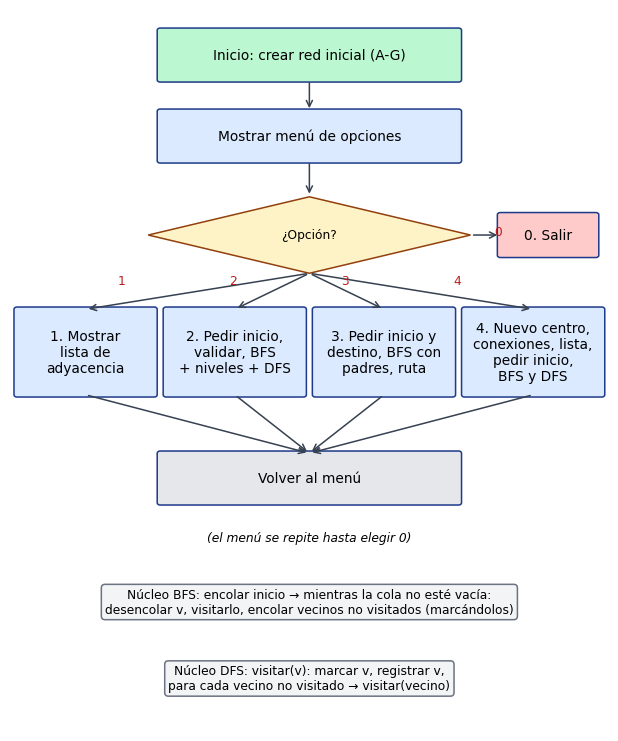


**Descripción del diagrama.** El programa crea la red inicial (A–G) y entra a un menú que se repite hasta que el usuario elige salir:
1. **Opción 1:** imprime la lista de adyacencia.
2. **Opción 2:** pide el centro inicial, valida que exista (si no, error y vuelve al menú) y ejecuta BFS (con niveles) y DFS.
3. **Opción 3:** pide inicio y destino, valida ambos y ejecuta BFS guardando el "padre" de cada centro para reconstruir la ruta; si no se alcanza el destino informa que no hay ruta.
4. **Opción 4:** pide el nuevo centro, lo conecta con los existentes indicados (en ambos sentidos), muestra la lista, pide el inicio y ejecuta BFS y DFS.
5. **Opción 0:** termina el programa.

**BFS:** se encola el inicio y, mientras la cola no esté vacía, se desencola un centro, se visita y se encolan sus vecinos no visitados. **DFS:** se marca y visita el centro y se llama recursivamente a cada vecino no visitado.

### 5) Análisis de complejidad **[15 pts]**

### Justificación
Sea **V** el número de vértices (centros) y **E** el número de aristas (carreteras). Con lista de adyacencia, cada arista no dirigida aparece **dos veces** (una en cada vecino), por lo que la suma de las longitudes de todas las listas es **2E**.

- **BFS:** cada vértice entra y sale de la cola **una sola vez** (gracias al conjunto de visitados) y, al desencolarlo, se revisan todos sus vecinos. Total: V desencolados + 2E vecinos revisados.
- **DFS:** cada vértice se visita una sola vez (una llamada recursiva por vértice) y en cada visita se recorre su lista de vecinos. Total: V visitas + 2E vecinos revisados.
- Las operaciones sobre `deque` (`append`, `popleft`) y sobre `set` (`in`, `add`) son **O(1)** en promedio. Con una matriz de adyacencia sería O(V²); la lista de adyacencia es mejor en redes poco densas como esta.
- **Búsqueda con BFS:** mismo recorrido pero se detiene al encontrar el destino. La reconstrucción de la ruta cuesta O(V) adicional en el peor caso.
- **Agregar centro/conexión:** `agregar_centro` es O(1). `agregar_conexion` es O(grado) por el chequeo de duplicados (`b in grafo[a]`), O(V) en el peor caso.

### Función T[n]
Contando como operación básica cada vértice procesado y cada vecino revisado, con n = V:

**T(V, E) = V + 2E**  →  **T(n) ∈ Θ(V + E)**

- Red inicial: V = 7, E = 7 → T = 7 + 14 = **21** operaciones.
- Grafo tipo cadena (E = n − 1): T(n) = 3n − 2 → lineal, O(n).
- Grafo completo (E = n(n−1)/2): T(n) = n + n(n−1) = n² → cuadrático, O(n²).

### Mejor y peor caso (búsqueda con BFS)
- **Mejor caso:** el centro buscado es el inicial; se encuentra al primer desencolado: **T = 1 → Ω(1)**.
- **Peor caso:** el destino no es alcanzable (o es el último en visitarse); se procesan todos los vértices y todas las aristas: **T = V + 2E → O(V + E)**.

La siguiente celda mide las operaciones reales con una versión instrumentada de BFS y las compara con la fórmula.

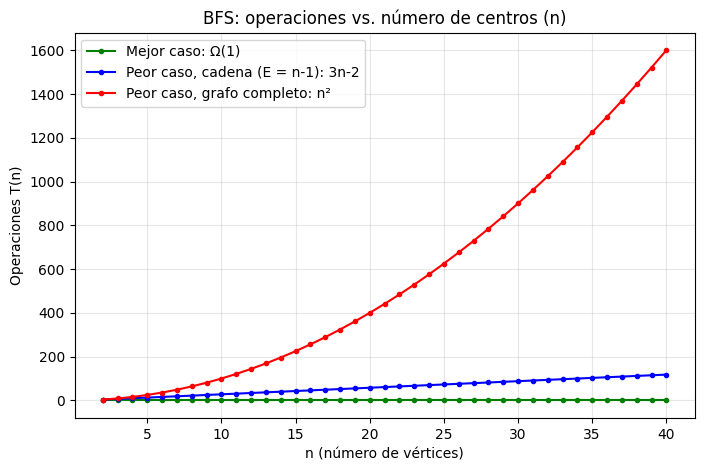

In [1]:
# Instala matplotlib automaticamente si no esta disponible
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
from collections import deque

def bfs_contando(grafo, inicio, destino):
    """BFS de búsqueda que cuenta operaciones: 1 por vértice desencolado + 1 por vecino revisado."""
    ops = 0
    visitados = {inicio}
    cola = deque([inicio])
    while cola:
        actual = cola.popleft()
        ops += 1
        if actual == destino:
            return ops
        for vecino in grafo[actual]:
            ops += 1
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)
    return ops

def grafo_cadena(n):
    g = {i: [] for i in range(n)}
    for i in range(n - 1):
        g[i].append(i + 1); g[i + 1].append(i)
    return g

def grafo_completo(n):
    return {i: [j for j in range(n) if j != i] for i in range(n)}

tamanos = list(range(2, 41))
mejor        = [bfs_contando(grafo_cadena(n), 0, 0) for n in tamanos]        # destino = inicio
peor_cadena  = [bfs_contando(grafo_cadena(n), 0, -1) for n in tamanos]       # destino inexistente
peor_completo = [bfs_contando(grafo_completo(n), 0, -1) for n in tamanos]

# Verificación contra la fórmula T = V + 2E
assert all(peor_cadena[i] == 3*n - 2 for i, n in enumerate(tamanos))
assert all(peor_completo[i] == n*n for i, n in enumerate(tamanos))
assert all(m == 1 for m in mejor)

plt.figure(figsize=(8, 5))
plt.plot(tamanos, mejor, "g-o", ms=3, label="Mejor caso: Ω(1)")
plt.plot(tamanos, peor_cadena, "b-o", ms=3, label="Peor caso, cadena (E = n-1): 3n-2")
plt.plot(tamanos, peor_completo, "r-o", ms=3, label="Peor caso, grafo completo: n²")
plt.title("BFS: operaciones vs. número de centros (n)")
plt.xlabel("n (número de vértices)")
plt.ylabel("Operaciones T(n)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


**Interpretación de la gráfica:** el mejor caso es constante (línea verde, siempre 1 operación). En el peor caso el costo crece con V + 2E: de forma lineal si la red es poco densa como una cadena o como la red de la empresa (azul) y cuadrática si todos los centros están conectados entre sí (rojo). Para una red de distribución real, que suele ser dispersa, el comportamiento es prácticamente lineal.

## 6) Código funcional **[15 pts]**
Implementación completa: lista de adyacencia, BFS (cola), DFS (recursivo), búsqueda de ruta, agregar centros/conexiones, dibujo del grafo y menú interactivo.

La primera celda define las funciones; la segunda ejecuta el menú interactivo.

In [ ]:
from collections import deque

# ---------- Punto 1: representación del grafo (lista de adyacencia) ----------
def agregar_centro(grafo, centro):
    """Agrega un vértice. Retorna False si ya existía."""
    if centro in grafo:
        return False
    grafo[centro] = []
    return True

def agregar_conexion(grafo, a, b):
    """Agrega la arista a-b en ambos sentidos (grafo no dirigido)."""
    if a not in grafo or b not in grafo or a == b:
        return False
    if b in grafo[a]:
        return False  # evita duplicados
    grafo[a].append(b)
    grafo[b].append(a)
    return True

def crear_red_inicial():
    grafo = {}
    for c in "ABCDEFG":
        agregar_centro(grafo, c)
    for a, b in [("A","B"), ("A","C"), ("B","D"), ("B","E"),
                 ("C","F"), ("E","G"), ("F","G")]:
        agregar_conexion(grafo, a, b)
    return grafo

def mostrar_grafo(grafo):
    print("Lista de adyacencia:")
    for centro, vecinos in grafo.items():
        print(f"  {centro}: {', '.join(vecinos) if vecinos else '(sin conexiones)'}")

# ---------- Punto 2: BFS con cola ----------
def bfs(grafo, inicio):
    """Retorna (orden de visita, diccionario de niveles)."""
    visitados = {inicio}
    niveles = {inicio: 0}
    cola = deque([inicio])
    orden = []
    while cola:
        actual = cola.popleft()
        orden.append(actual)
        for vecino in grafo[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                niveles[vecino] = niveles[actual] + 1
                cola.append(vecino)
    return orden, niveles

def mostrar_niveles(niveles):
    por_nivel = {}
    for centro, nivel in niveles.items():
        por_nivel.setdefault(nivel, []).append(centro)
    for nivel in sorted(por_nivel):
        print(f"  Nivel {nivel}: {', '.join(por_nivel[nivel])}")

# ---------- Punto 3: DFS recursivo ----------
def dfs(grafo, inicio):
    visitados = set()
    orden = []
    def visitar(v):
        visitados.add(v)
        orden.append(v)
        for vecino in grafo[v]:
            if vecino not in visitados:
                visitar(vecino)
    visitar(inicio)
    return orden

# ---------- Punto 5: búsqueda de ruta con BFS ----------
def buscar_ruta_bfs(grafo, inicio, destino):
    """Retorna la ruta más corta (lista) o None si no hay ruta."""
    visitados = {inicio}
    padre = {inicio: None}
    cola = deque([inicio])
    while cola:
        actual = cola.popleft()
        if actual == destino:
            ruta = []
            while actual is not None:
                ruta.append(actual)
                actual = padre[actual]
            return ruta[::-1]
        for vecino in grafo[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                padre[vecino] = actual
                cola.append(vecino)
    return None


# ---------- Dibujo del grafo ----------
POSICIONES_INICIALES = {"A": (2, 3), "B": (1, 2), "C": (3, 2), "D": (0, 1),
                        "E": (1.5, 1), "F": (3, 1), "G": (2.25, 0)}

def _importar_pyplot():
    try:
        import matplotlib.pyplot as plt
    except ModuleNotFoundError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
        import matplotlib.pyplot as plt
    return plt

def dibujar_grafo(grafo, inicio=None, titulo="Red de distribución"):
    """Dibuja la red. Si se da 'inicio', colorea cada centro según su nivel BFS."""
    import math
    plt = _importar_pyplot()
    if set(grafo) == set(POSICIONES_INICIALES):
        pos = dict(POSICIONES_INICIALES)
    else:  # red ampliada: distribución circular
        n = len(grafo)
        pos = {c: (math.cos(2 * math.pi * i / n), math.sin(2 * math.pi * i / n))
               for i, c in enumerate(grafo)}
    niveles = bfs(grafo, inicio)[1] if inicio else {}
    paleta = ["#4ade80", "#60a5fa", "#fbbf24", "#f472b6", "#a78bfa", "#fb923c"]

    plt.figure(figsize=(6, 5))
    for a in grafo:                      # aristas (cada una se dibuja una vez)
        for b in grafo[a]:
            if a < b:
                plt.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], "k-", zorder=1)
    for c, (x, y) in pos.items():        # vértices
        color = paleta[niveles[c] % len(paleta)] if c in niveles else "#d1d5db"
        plt.scatter(x, y, s=900, c=color, edgecolors="black", zorder=2)
        plt.text(x, y, c, ha="center", va="center", fontsize=13, fontweight="bold", zorder=3)
    if niveles:
        titulo += f" (color = nivel BFS desde {inicio})"
    plt.title(titulo, fontsize=10)
    plt.margins(0.15)
    plt.axis("off")
    plt.show()

# ---------- Utilidades de interacción ----------
def leer_centro(grafo, mensaje):
    """Pide un centro existente; retorna None y muestra error si no existe."""
    centro = input(mensaje).strip().upper()
    if centro not in grafo:
        print(f"Error: el centro '{centro}' no existe en la red.")
        return None
    return centro

def ejecutar_recorridos(grafo, inicio):
    orden, niveles = bfs(grafo, inicio)
    print(f"\nRecorrido BFS desde {inicio}: {' -> '.join(orden)}")
    mostrar_niveles(niveles)
    print(f"Recorrido DFS desde {inicio}: {' -> '.join(dfs(grafo, inicio))}")

def menu():
    grafo = crear_red_inicial()
    mostrar_grafo(grafo)
    while True:
        print("\n===== RED DE DISTRIBUCIÓN =====")
        print("1. Mostrar lista de adyacencia")
        print("2. Recorridos BFS y DFS desde un centro")
        print("3. Buscar un centro (BFS)")
        print("4. Agregar centro y conexiones")
        print("5. Dibujar la red")
        print("0. Salir")
        opcion = input("Opción: ").strip()

        if opcion == "1":
            mostrar_grafo(grafo)
        elif opcion == "2":
            inicio = leer_centro(grafo, "Ingrese el centro inicial: ")
            if inicio:
                ejecutar_recorridos(grafo, inicio)
        elif opcion == "3":
            inicio = leer_centro(grafo, "Centro inicial: ")
            if not inicio:
                continue
            destino = leer_centro(grafo, "Centro que desea buscar: ")
            if not destino:
                continue
            ruta = buscar_ruta_bfs(grafo, inicio, destino)
            if ruta:
                print(f"Centro encontrado. Ruta: {' -> '.join(ruta)}")
                print(f"Cantidad de conexiones: {len(ruta) - 1}")
            else:
                print("No existe una ruta hasta el centro solicitado.")
        elif opcion == "4":
            nuevo = input("Ingrese el nuevo centro: ").strip().upper()
            if not nuevo:
                print("Error: el nombre no puede estar vacío.")
                continue
            if not agregar_centro(grafo, nuevo):
                print(f"Error: el centro '{nuevo}' ya existe.")
                continue
            while True:
                otro = input("Conectar con (Enter para terminar): ").strip().upper()
                if otro == "":
                    break
                if otro not in grafo:
                    print(f"Error: el centro '{otro}' no existe.")
                elif not agregar_conexion(grafo, nuevo, otro):
                    print("No se pudo agregar (conexión repetida o inválida).")
                else:
                    print(f"Conexión agregada: {nuevo} - {otro}")
            print()
            mostrar_grafo(grafo)
            inicio = leer_centro(grafo, "\nIngrese el centro inicial para los recorridos: ")
            if inicio:
                ejecutar_recorridos(grafo, inicio)
                dibujar_grafo(grafo, inicio)
        elif opcion == "5":
            inicio = input("Centro inicial para colorear por niveles (Enter = sin colorear): ").strip().upper()
            if inicio and inicio not in grafo:
                print(f"Error: el centro '{inicio}' no existe en la red.")
            else:
                dibujar_grafo(grafo, inicio or None)
        elif opcion == "0":
            print("Programa finalizado.")
            break
        else:
            print("Opción no válida.")


### Dibujo de la red
Grafo original coloreado por nivel BFS desde A (cada color es un nivel).

In [ ]:
dibujar_grafo(crear_red_inicial(), inicio="A")


In [ ]:
# Ejecuta el programa interactivo (pide datos por teclado)
if "crear_red_inicial" not in globals():
    raise RuntimeError("Primero ejecuta la celda anterior (funciones de la seccion 6).")
try:
    menu()
except (EOFError, KeyboardInterrupt):
    print("\nPrograma interrumpido.")


Lista de adyacencia:
  A: B, C
  B: A, D, E
  C: A, F
  D: B
  E: B, G
  F: C, G
  G: E, F

===== RED DE DISTRIBUCIÓN =====
1. Mostrar lista de adyacencia
2. Recorridos BFS y DFS desde un centro
3. Buscar un centro (BFS)
4. Agregar centro y conexiones
5. Dibujar la red
0. Salir


## 7) Tests aplicados **[15 pts]**

In [ ]:
# Tests con asserts (cubren los 6 puntos del laboratorio)
if 'crear_red_inicial' not in globals():
    raise RuntimeError('Primero ejecuta la celda de funciones de la seccion 6.')

g = crear_red_inicial()

# Punto 1: lista de adyacencia y bidireccionalidad
assert g == {"A": ["B","C"], "B": ["A","D","E"], "C": ["A","F"], "D": ["B"],
             "E": ["B","G"], "F": ["C","G"], "G": ["E","F"]}
assert all(u in g[v] for u in g for v in g[u])  # no dirigido

# Punto 2: BFS y niveles
orden, niveles = bfs(g, "A")
assert orden == ["A","B","C","D","E","F","G"]
assert niveles == {"A":0, "B":1, "C":1, "D":2, "E":2, "F":2, "G":3}

# Punto 3: DFS y visita única
assert dfs(g, "A") == ["A","B","D","E","G","F","C"]
for ini in g:
    assert len(bfs(g, ini)[0]) == len(set(bfs(g, ini)[0])) == len(g)
    assert len(dfs(g, ini)) == len(set(dfs(g, ini))) == len(g)

# Punto 4: otro inicio
assert bfs(g, "B")[0] == ["B","A","D","E","C","G","F"]
assert dfs(g, "B") == ["B","A","C","F","G","E","D"]

# Punto 5: búsqueda de ruta
assert buscar_ruta_bfs(g, "A", "F") == ["A","C","F"]          # 2 conexiones
assert buscar_ruta_bfs(g, "A", "A") == ["A"]                   # 0 conexiones
assert buscar_ruta_bfs(g, "D", "G") == ["D","B","E","G"]
agregar_centro(g, "Z")                                         # centro aislado
assert buscar_ruta_bfs(g, "A", "Z") is None
del g["Z"]

# Punto 6: agregar centros y conexiones
assert agregar_centro(g, "H") is True
assert agregar_centro(g, "H") is False                         # duplicado
assert agregar_conexion(g, "H", "D") and agregar_conexion(g, "H", "G")
assert agregar_conexion(g, "H", "D") is False                  # arista repetida
assert agregar_conexion(g, "H", "X") is False                  # centro inexistente
assert agregar_conexion(g, "H", "H") is False                  # lazo
assert g["D"] == ["B","H"] and g["G"] == ["E","F","H"] and g["H"] == ["D","G"]
assert bfs(g, "A")[0] == ["A","B","C","D","E","F","H","G"]
assert dfs(g, "A") == ["A","B","D","H","G","E","F","C"]
assert buscar_ruta_bfs(g, "A", "H") == ["A","B","D","H"]

print("Todos los tests pasaron")
